<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/exoplanet_trappist1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exoplanet Discovery for TRAPPIST-1**

[TRAPPIST-1](https://en.m.wikipedia.org/wiki/TRAPPIST-1) is a cool red dwarf star[c] with seven known exoplanets. It lies in constellation Aquarius 40.66 light-years away from Earth

In [ ]:
# Lightkurve library installed, which is specifically designed to work with Kepler and TESS data.
!pip install lightkurve -q
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

In [59]:
target = 'Trappist-1'
# target = 'Kepler-10'
# target = 'Kepler-8'

#### **Part 0**

In [109]:
# Search and download light curve data for a specific target (Kepler ID or TIC ID)
lc_search = lk.search_lightcurve(target, mission="Kepler") # or mission="TESS"
print(lc_search)

SearchResult containing 48 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 14 2019   SPOC     120   377780790      0.0
  1 TESS Sector 40 2021   SPOC      20   377780790      0.0
  2 TESS Sector 41 2021   SPOC      20   377780790      0.0
  3 TESS Sector 40 2021   SPOC     120   377780790      0.0
  4 TESS Sector 41 2021   SPOC     120   377780790      0.0
  5 TESS Sector 55 2022   SPOC      20   377780790      0.0
  6 TESS Sector 54 2022   SPOC      20   377780790      0.0
  7 TESS Sector 53 2022   SPOC      20   377780790      0.0
  8 TESS Sector 55 2022   SPOC     120   377780790      0.0
...            ...  ...    ...     ...         ...      ...
 38 TESS Sector 14 2019  TASOC    1800   377780790      0.0
 39 TESS Sector 14 2019  TASOC    1800   377780790      0.0
 40 TESS Sector 26 2020  CDIPS    1800   377780790      0

/usr/local/lib/python3.10/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

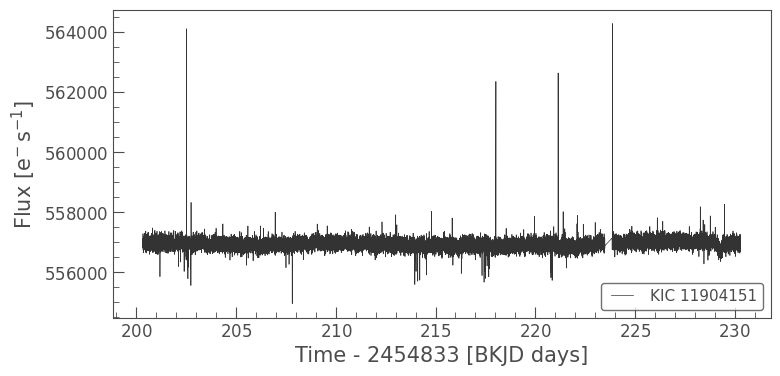

In [40]:
# Download the data (just grabbing the first result here)
lc = lc_search.download(quality_bitmask="default")

# Plot the light curve
lc.plot(title=f"Light Curve for {target}")

<Axes: title={'center': 'Periodogram - Transit Detection'}, xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

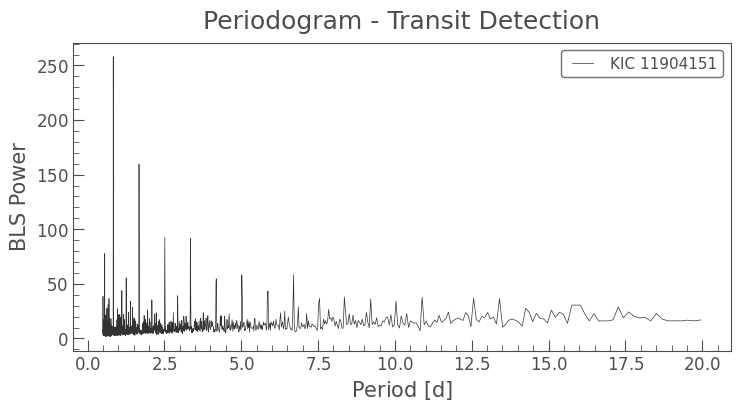

In [41]:
# Clean the data by removing NaN values and flattening the curve
cleaned_lc = lc.remove_nans().flatten(window_length=401)

# Detect transits: Use a Box Least Squares (BLS) periodogram to find periodic dips in brightness, which could indicate planetary transits
periodogram = cleaned_lc.to_periodogram(method="bls", minimum_period=0.5, maximum_period=20)

# Plot the BLS periodogram to visualize detected periods (periodogram helps to visualize and extract the best-fit period, i.e. the time between transits
periodogram.plot(title="Periodogram - Transit Detection")

In [42]:
# Get the best-fit transit period and duration
best_fit_period = periodogram.period_at_max_power
best_fit_duration = periodogram.duration_at_max_power
best_fit_depth = periodogram.depth_at_max_power

print(f"Best-fit period: {best_fit_period:.2f} days")
print(f"Best-fit transit duration: {best_fit_duration:.2f} days")
print(f"Transit depth: {best_fit_depth:.6f} relative flux")

Best-fit period: 0.84 d days
Best-fit transit duration: 0.05 d days
Transit depth: 0.000092 relative flux


Estimated planet radius: 0.01 solar radii


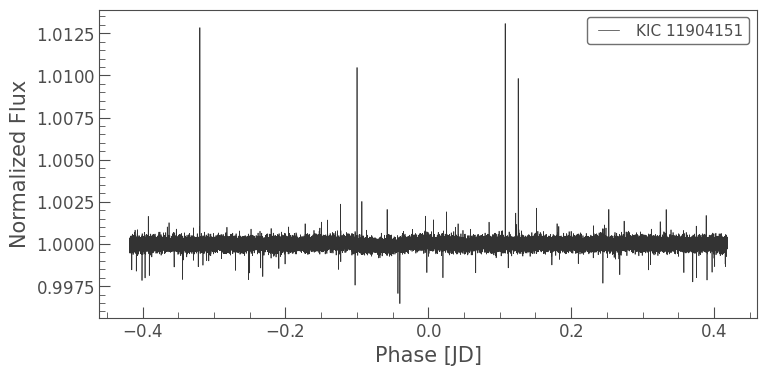

In [45]:
# Fold the light curve by the detected period to see the repeated transits (By folding the light curve by detected period, observe repeated transits more clearly)
folded_lc = cleaned_lc.fold(period=best_fit_period.value)
folded_lc.plot(title=f"Folded Light Curve for {target} - Period: {best_fit_period:.2f} days")

# Estimate the planet radius using the transit depth (assuming the star's radius is known) -
# Using the depth of the transit and the star's radius, we estimate the planet's radius.
# Formula: (Rp/Rs)^2 = depth
# Rp = planet radius, Rs = star radius, depth = fractional dip in brightness
star_radius = 1.065  # Solar radii for Kepler-10
planet_radius = star_radius * np.sqrt(best_fit_depth)

print(f"Estimated planet radius: {planet_radius:.2f} solar radii")

#### **Part 1**

In [60]:
# Download exoplanet details
pixelfile = lk.search_targetpixelfile(target)[1].download()
pixelfile

KeplerTargetPixelFile Object (ID: 11904151)

In [51]:
pixelfile.animate()

In [52]:
pixelfile.to_lightcurve(method="pld")

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float64,float64,float64,float64,int32,int32
2905.3769167939536,5658.061937822705,4.79782582157124,992.4287843178472,26.701936679686334,136855,524288
2905.397348964376,5673.688368326501,4.799150852752048,992.3999443617888,26.721656520982215,136856,0
2905.417781134791,5670.192447281816,4.7957925476054495,992.3700333780516,26.746472098341595,136857,0
2905.438213304282,5677.435432973874,4.796658489298969,992.3359655032883,26.770288756747608,136858,0
2905.458645473307,5684.625294102683,4.798489078504132,992.305224750422,26.792247181397425,136859,0
2905.4790776418595,5685.2170264016095,4.798159150944555,992.2756494525472,26.81326669279269,136860,0
2905.4995098099535,5692.814484947588,4.797523479553304,992.2381306803679,26.84120553324434,136861,0
2905.5199419775818,5694.116013969211,4.798178231710627,992.1958975564798,26.870287638624163,136862,0


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

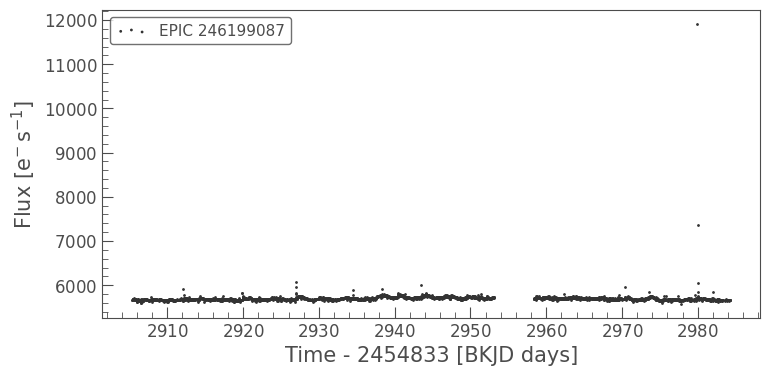

In [53]:
pixelfile.to_lightcurve(method="pld").scatter()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

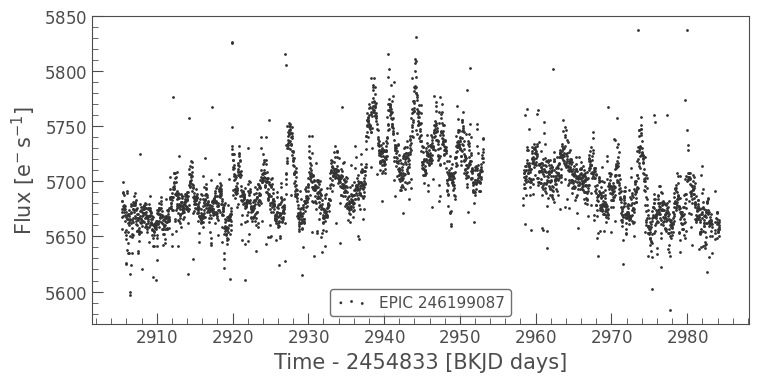

In [54]:
pixelfile.to_lightcurve(method="pld").remove_outliers().scatter()

In [56]:
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten()

In [57]:
lc.to_periodogram("bls").period_at_max_power

<Quantity 1.51103729 d>

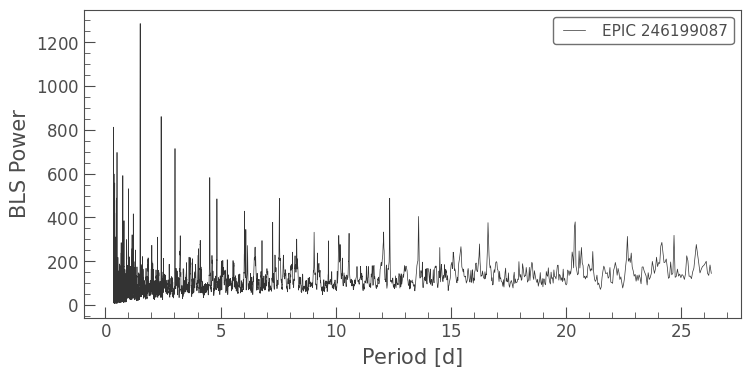

In [58]:
lc.to_periodogram("bls").plot();

In [11]:
period = lc.to_periodogram("bls").period_at_max_power

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

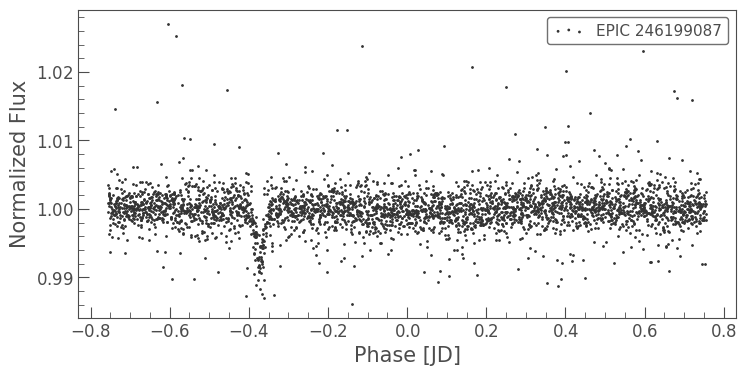

In [12]:
lc.fold(period).scatter()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

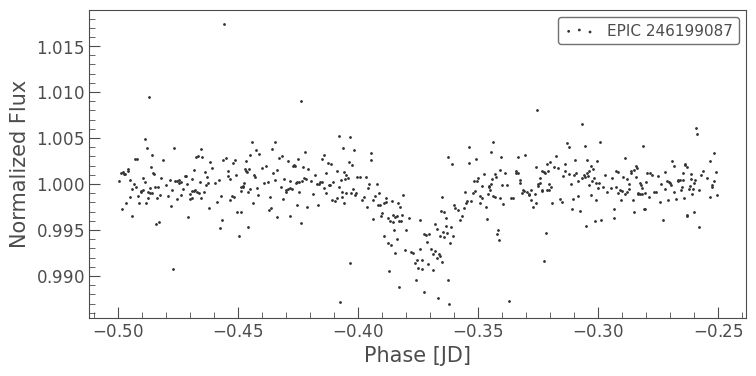

In [13]:
lc.fold(period).truncate(-0.5, -0.25).scatter() # planet?

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

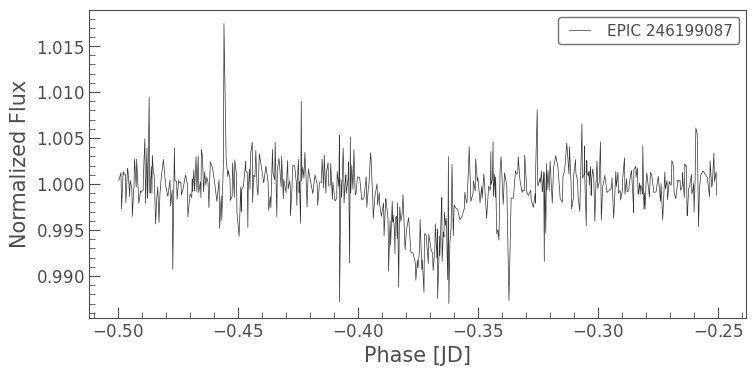

In [14]:
lc.fold(period).truncate(-0.5, -0.25).plot()

#### **Part 2**

In [61]:
# Missions that inspected this exoplanet system
datalist = lk.search_targetpixelfile(target)
datalist

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 02,2009,Kepler,60,kplr011904151,0.0
4,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 05,2010,Kepler,60,kplr011904151,0.0


In [64]:
# Get Kepler data if available
kep = datalist[(datalist.author == "Kepler") & (datalist.exptime == 60*u.second)][0].download()

In [67]:
# Get TESS data if available
tes = datalist[(datalist.author == "SPOC") & (datalist.exptime == 120*u.second)][0].download()

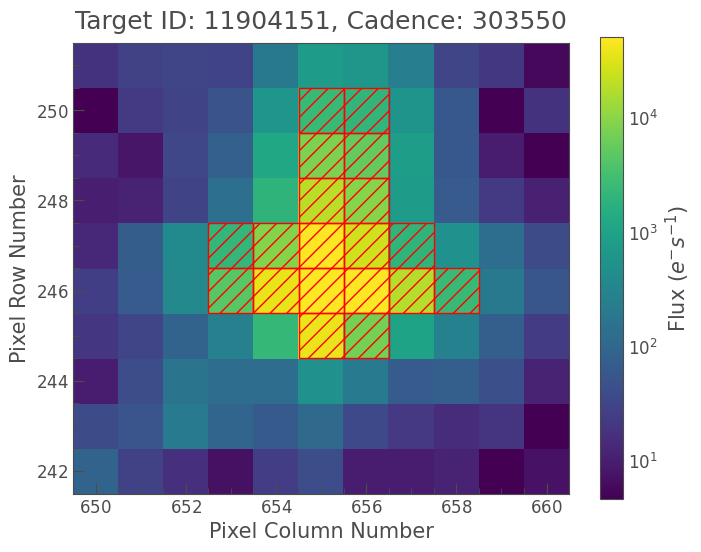

In [85]:
kep.plot(aperture_mask=kep.pipeline_mask, scale='log')
fig = plt.gcf()
fig.set_size_inches(8, 6)
plt.show()

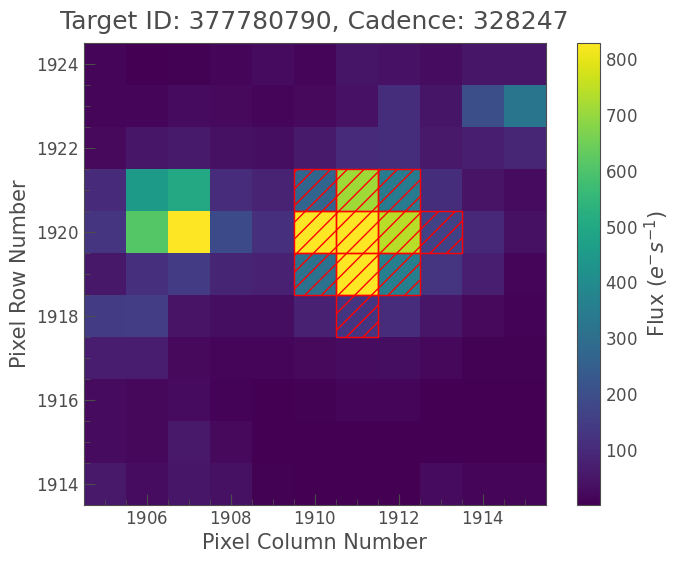

In [84]:
tes.plot(aperture_mask=tes.pipeline_mask)
fig = plt.gcf()
fig.set_size_inches(8, 6)
plt.show()

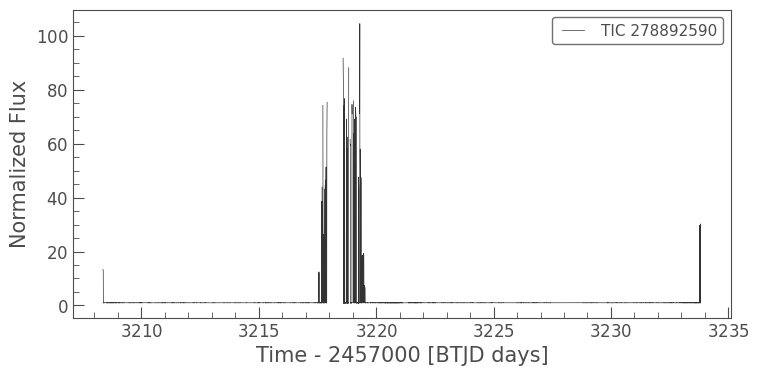

In [24]:
lc = tes.to_lightcurve()
lc.flatten().plot(c='k', alpha=.8)

In [25]:
# Apply pls method and remove outliers
lc = tes.to_lightcurve(method="pld").remove_outliers().flatten()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

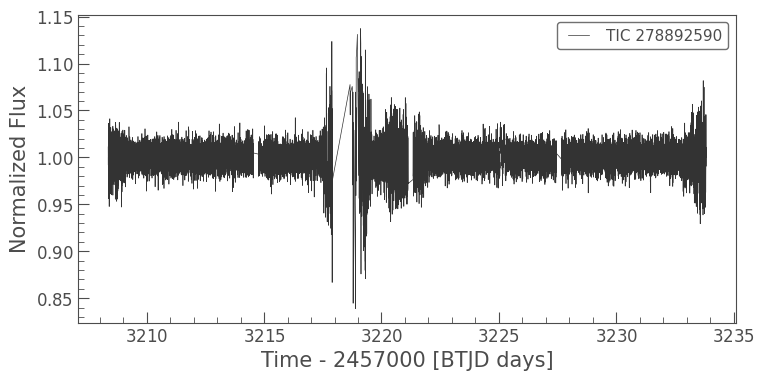

In [26]:
lc.flatten().plot(c='k', alpha=.8)

In [27]:
# Define period
period = lc.to_periodogram("bls").period_at_max_power
period

<Quantity 0.33689913 d>

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

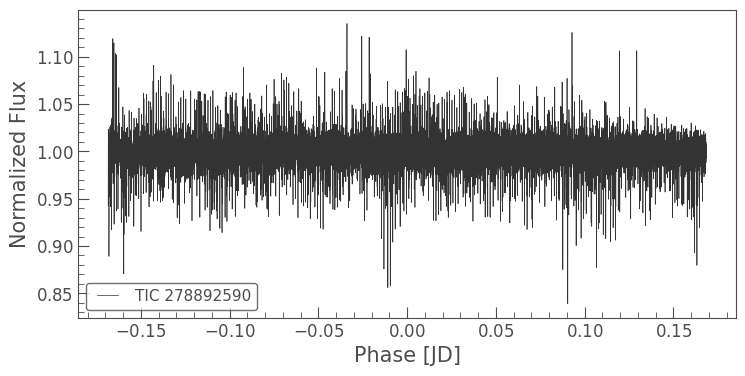

In [28]:
lc.fold(period).plot() #.truncate(-0.5, -0.25).plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

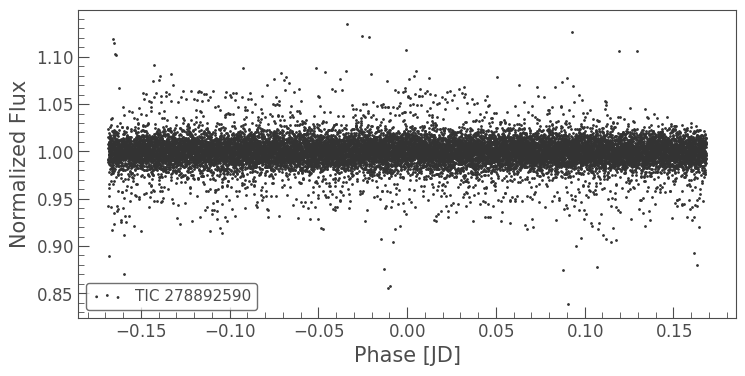

In [29]:
lc.fold(period).scatter() #truncate(-0.5, -0.25).scatter()

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

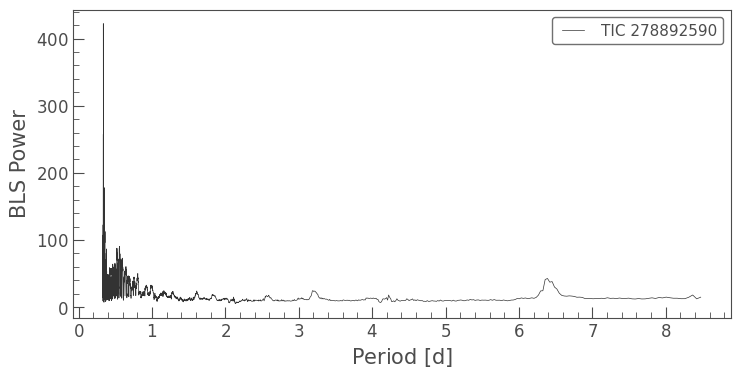

In [30]:
lc.to_periodogram("bls").plot()

#### **Part 3**

A TPF contains the original imaging data from which a light curve is derived. Besides the brightness data measured by the charge-coupled device (CCD) camera, a TPF also includes post-processing information such as an estimate of the astronomical background, and a recommended pixel aperture for extracting a light curve.

In [87]:
# one quarter of Kepler data for star Kepler-8
search_result = lk.search_targetpixelfile(target, author="Kepler", quarter=4, cadence="long")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 04,2010,Kepler,1800,kplr011904151,0.0


In [88]:
tpf = search_result.download()

# focus on first cadence, select using zero-based indexing:
first_cadence = tpf[0]
first_cadence

KeplerTargetPixelFile Object (ID: 11904151)

At each cadence the TPF has a number of photometry data properties. These are:
* flux_bkg: the astronomical background of the image.
* flux_bkg_err: the statistical uncertainty on the background flux.
* flux: the stellar flux after the background is removed.
* flux_err: the statistical uncertainty on the stellar flux after background removal.

In [89]:
first_cadence.flux.value

array([[[7.73749619e+01, 3.46947052e+02, 2.20518066e+02, 3.79315521e+02,
         3.80010315e+02, 2.15071472e+02, 6.53416824e+01],
        [4.02104721e+01, 1.61733627e+02, 6.00123108e+02, 4.26371875e+03,
         5.84965381e+03, 1.73036218e+03, 1.15752777e+02],
        [6.44878922e+01, 1.79528809e+02, 9.81661194e+02, 1.58747451e+04,
         1.03636344e+05, 1.04178857e+04, 2.48488586e+02],
        [1.19196304e+02, 8.41078308e+02, 7.62989209e+03, 5.26318828e+04,
         1.65955812e+05, 5.14977734e+04, 9.95569824e+02],
        [6.57846069e+01, 2.12042526e+02, 1.02041870e+03, 1.22960703e+04,
         6.86683438e+04, 1.24292881e+04, 3.10381866e+02],
        [1.92761345e+01, 8.80226898e+01, 6.80371460e+02, 7.20903418e+03,
         1.98590645e+04, 7.52598340e+03, 4.91969910e+02],
        [2.95421028e+01, 4.68371201e+01, 4.16405762e+02, 3.34006250e+03,
         7.72133740e+03, 3.61071167e+03, 3.72761444e+02],
        [2.07859554e+01, 2.03018646e+01, 1.84162079e+02, 1.25146985e+03,
         2

When plotting data using the plot() function, what you are seeing in the TPF is the flux after the background has been removed. This background flux typically consists of zodiacal light or earthshine (especially in TESS observations). The background is typically smooth and changes on scales much larger than a single TPF. In Kepler, the background is estimated for the CCD as a whole, before being extracted from each TPF in that CCD. You can learn more about background removal in Section 4.2 of the Kepler Data Processing Handbook.

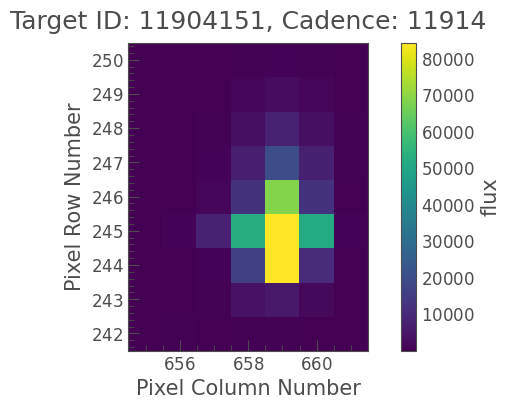

In [90]:
first_cadence.plot(column='flux')

Now, let’s compare the background to the background-subtracted flux to get a sense of scale. We can do this using the plot() function’s column keyword. By default the function plots the flux, but we can change this to plot the background, as well as other data such as the error on each pixel’s flux.

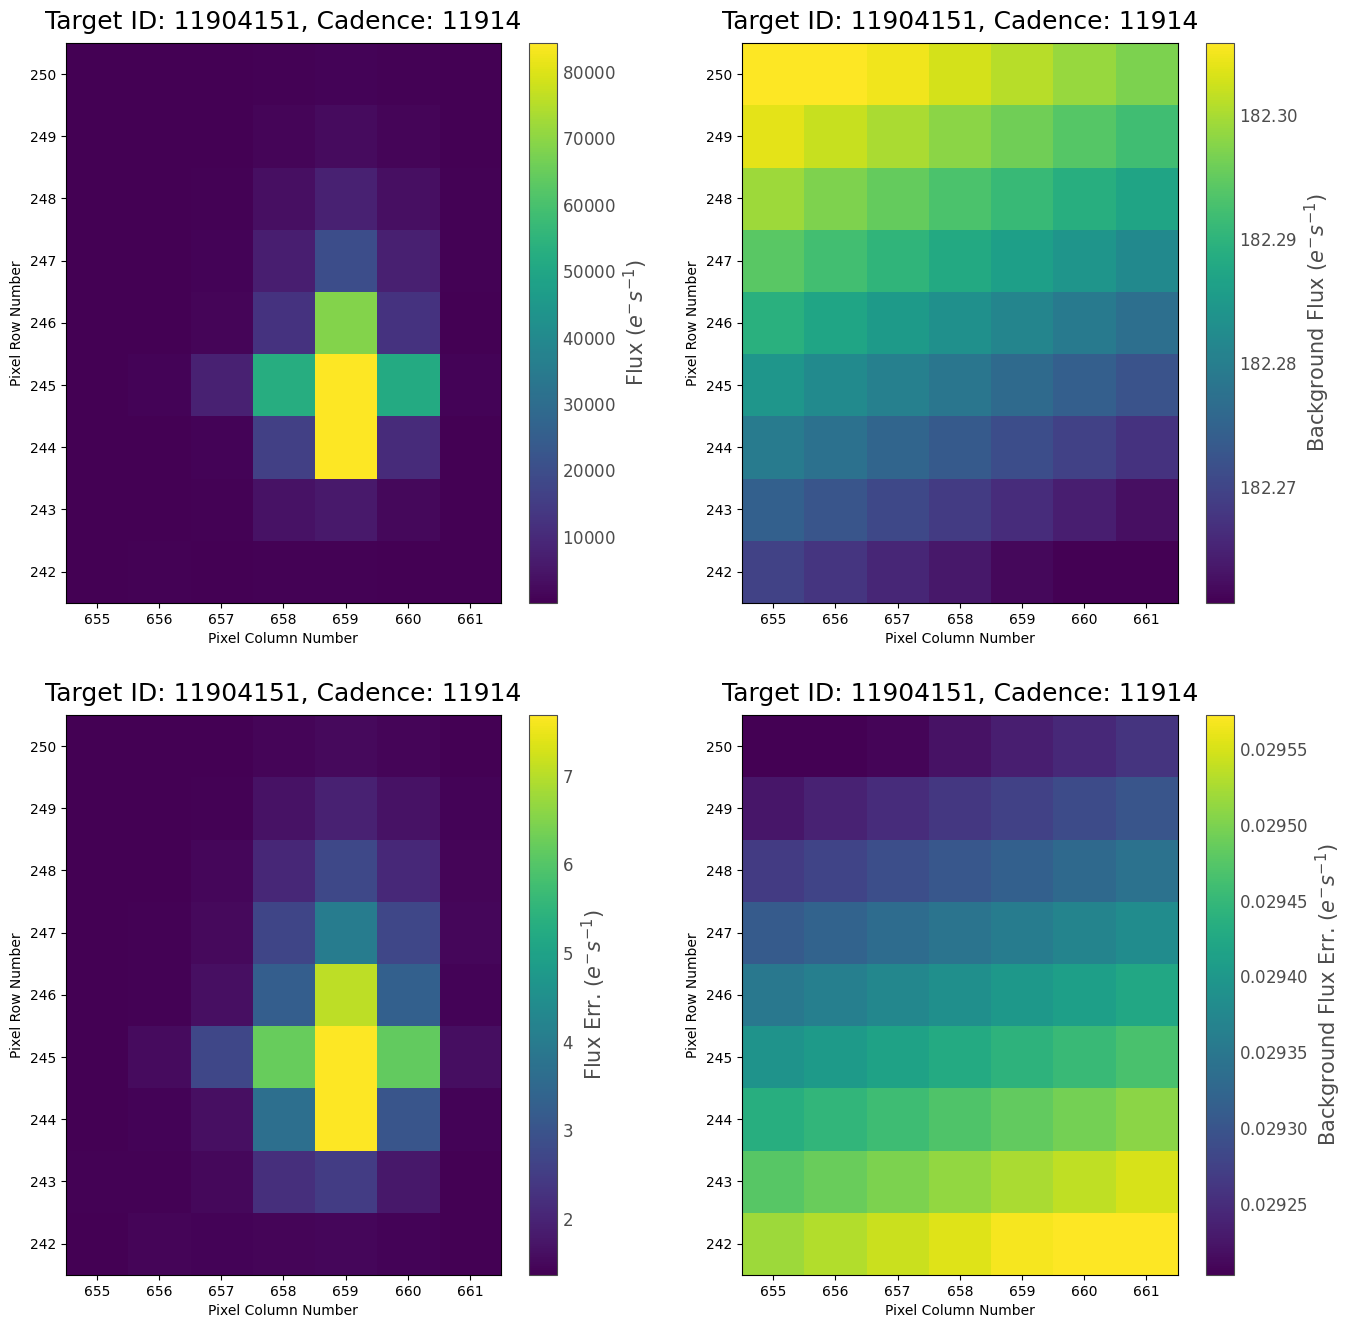

In [91]:
fig, axes = plt.subplots(2,2, figsize=(16,16))
first_cadence.plot(ax=axes[0,0], column='FLUX')
first_cadence.plot(ax=axes[0,1], column='FLUX_BKG')
first_cadence.plot(ax=axes[1,0], column='FLUX_ERR')
first_cadence.plot(ax=axes[1,1], column='FLUX_BKG_ERR');

From looking at the color scale on both plots, you may see that the background flux is very low compared to the total flux emitted by a star. This is expected — stars are bright! But these small background corrections become important when looking at the very small scale changes caused by planets or stellar oscillations. Understanding the background is an important part of astronomy with Kepler, K2, and TESS.

If the background is particularly bright and you want to see what the TPF looks like with it included, passing the bkg=True argument to the plot() method will show the TPF with the flux added on top of the background, representing the total flux recorded by the spacecraft.

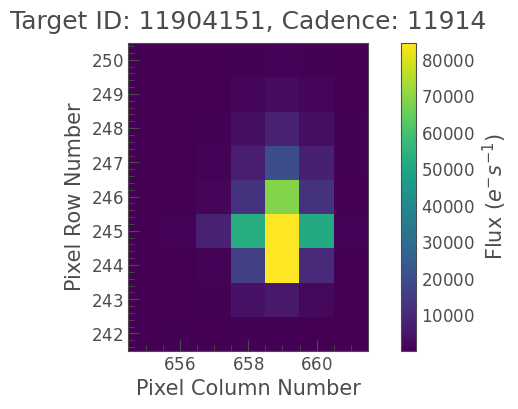

In [92]:
first_cadence.plot(bkg=True);

In this case, the background is low and the star is bright, so it doesn’t appear to make much of a difference.


As part of the data processing done by the Kepler pipeline, each TPF includes a recommended optimal aperture mask. This aperture mask is optimized to ensure that the stellar signal has a high signal-to-noise ratio, with minimal contamination from the background. The optimal aperture is stored in the TPF as the pipeline_mask property.

In [93]:
first_cadence.pipeline_mask

array([[False, False, False, False, False, False, False],
       [False, False, False,  True,  True, False, False],
       [False, False, False,  True,  True,  True, False],
       [False, False,  True,  True,  True,  True, False],
       [False, False, False,  True,  True,  True, False],
       [False, False, False,  True,  True,  True, False],
       [False, False, False,  True,  True,  True, False],
       [False, False, False, False,  True, False, False],
       [False, False, False, False, False, False, False]])

It is a Boolean array detailing which pixels are included. We can plot this aperture over the top of our TPF using the plot() function, and passing in the mask to the aperture_mask keyword. This will highlight the pixels included in the aperture mask using red hatched lines.


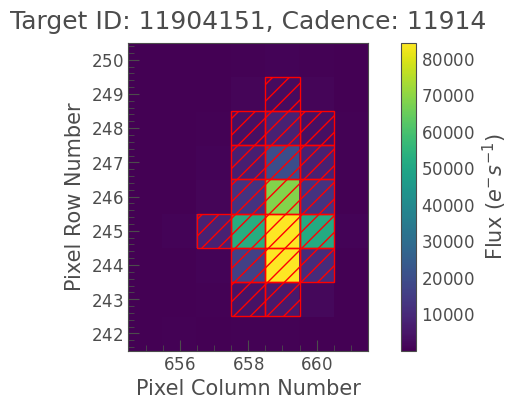

In [94]:
first_cadence.plot(aperture_mask=first_cadence.pipeline_mask);

**Simple Aperture Photometry**

You don’t necessarily have to pass in the pipeline_mask to the plot() function; it can be any mask you create yourself, provided it is the right shape. An accompanying tutorial explains how to create such custom apertures, and goes into aperture photometry in more detail. For specifics on the selection of Kepler’s optimal apertures, read the [Kepler Data Processing Handbook, Section 7, Finding Optimal Apertures in Kepler Data](https://archive.stsci.edu/files/live/sites/mast/files/home/missions-and-data/kepler/_documents/KSCI-19081-002-KDPH.pdf).

Perform simple aperture photometry (SAP) using the provided optimal aperture in pipeline_mask and the TPF. Using the full TPF for all cadences in the quarter, we can perform aperture photometry using the to_lightcurve() method as follows:

In [95]:
lc = tpf.to_lightcurve()
# This method returns a LightCurve object which details the flux and flux centroid position at each cadence:
lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int32,int32
352.37710510943725,562954.5625,20.549448013305664,658.9549290430009,245.1183011252407,11914,0
352.3975382855133,562910.1875,20.54881477355957,658.9549695555168,245.11830252327178,11915,0
352.43840463818196,562950.4375,20.548032760620117,658.9548812104192,245.118697011269,11917,16
352.4588378147819,562939.1875,20.54869842529297,658.9547350280822,245.11865153443182,11918,8192
352.47927099154913,562964.5625,20.54947853088379,658.9548263370721,245.11857623587096,11919,0
352.4997041685565,562967.0,20.548015594482422,658.9548674210249,245.11876627130025,11920,0
352.52013734568027,562952.3125,20.548452377319336,658.9547272524096,245.11874459254264,11921,0
352.54057042302884,562950.375,20.548309326171875,658.955012176067,245.11874260167014,11922,0


Note that this KeplerLightCurve object has fewer data columns than in light curves downloaded directly from MAST. This is because we are extracting our light curve directly from the TPF using minimal processing, whereas light curves created using the official pipeline include more processing and more columns.

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

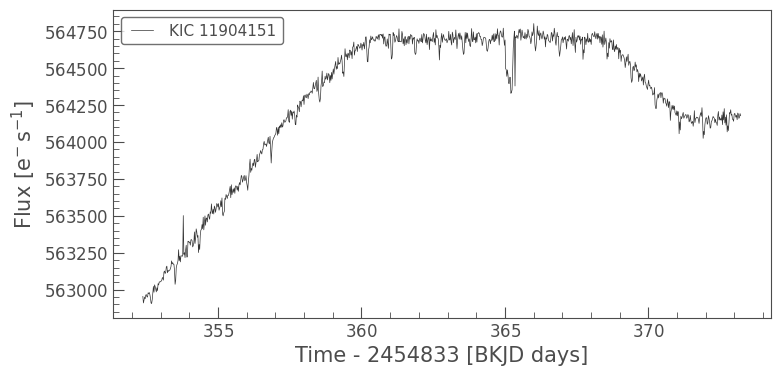

In [96]:
lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

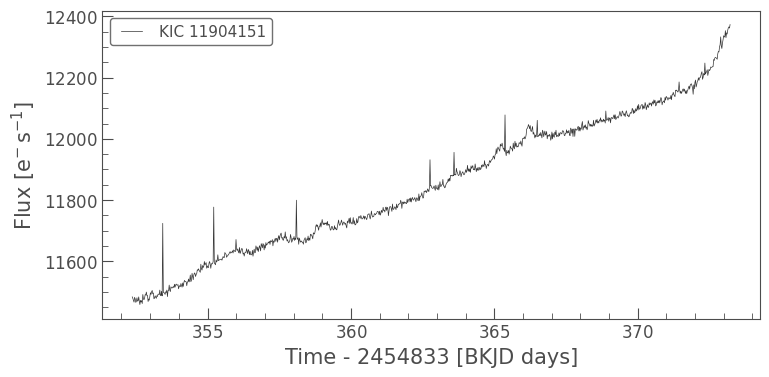

In [97]:
bkg = tpf.get_bkg_lightcurve()
bkg.plot()

Inspecting the background in this way is useful to identify signals which appear to be present in the background rather than in the astronomical object under study.

In [98]:
from lightkurve import search_targetpixelfile

# First we open a Target Pixel File from MAST, this one is already cached from our previous tutorial!
tpf = search_targetpixelfile('KIC 6922244', author="Kepler", cadence="long", quarter=4).download()

# Then we convert the target pixel file into a light curve using the pipeline-defined aperture mask.
lc = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)

In [99]:
lc.meta['MISSION']

'Kepler'

In [100]:
lc.meta['QUARTER']

4

In [101]:
lc.time

<Time object: scale='tdb' format='bkjd' value=[352.37632485 352.39675805 352.43762445 ... 442.16263546 442.18306983
 442.2035041 ]>

In [102]:
lc.flux

<Quantity [43689.15 , 43698.08 , 43694.105, ..., 43155.8  , 43148.465,
           43151.562] electron / s>

In [103]:
lc.estimate_cdpp()

<Quantity 75.29876612 ppm>

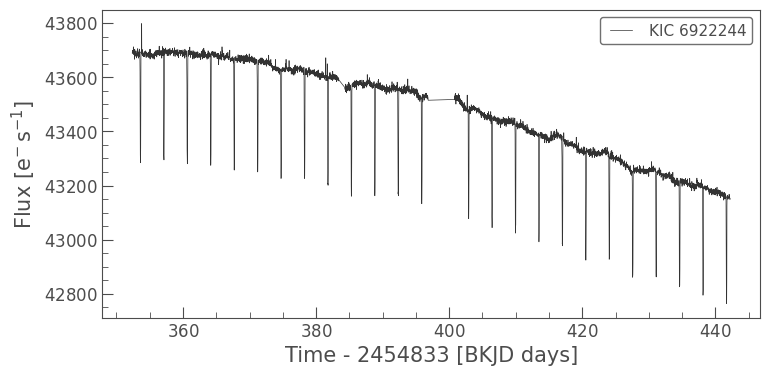

In [104]:
%matplotlib inline
lc.plot();

flatten(): Remove long term trends using a [Savitzky–Golay filter](https://en.m.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter)

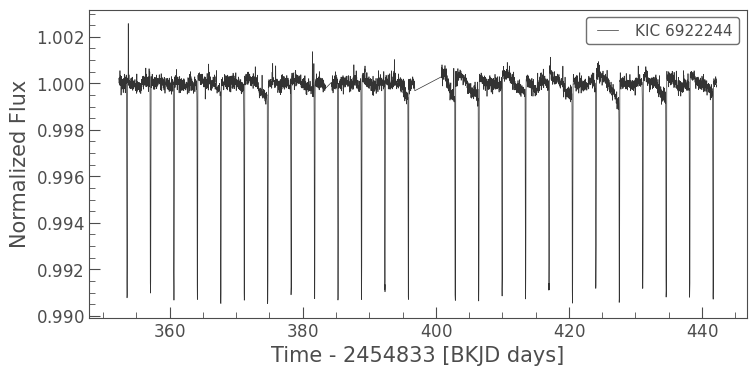

In [105]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();

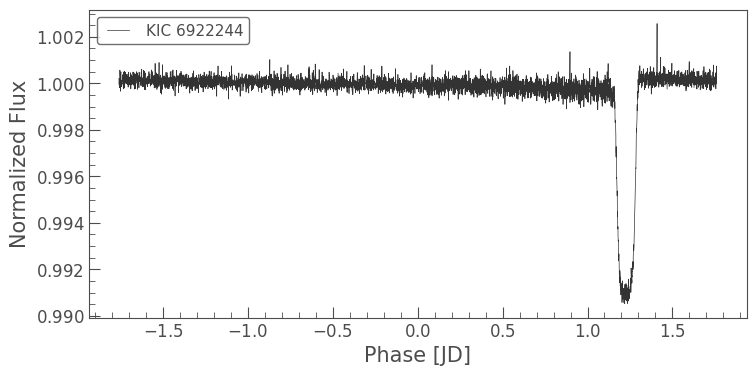

In [106]:
folded_lc = flat_lc.fold(period=3.5225) # fold(): Fold the data at a particular period
folded_lc.plot();

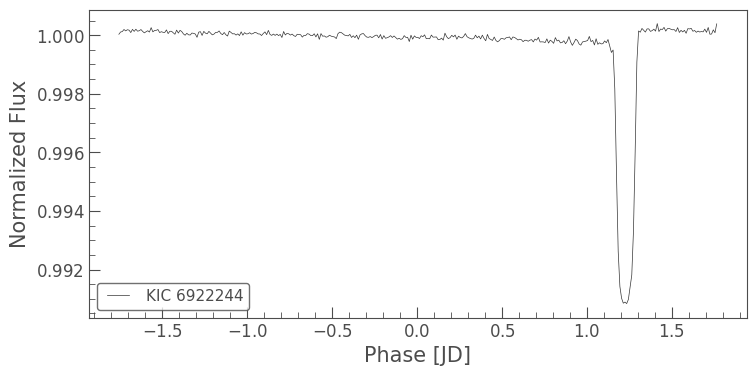

In [107]:
binned_lc = folded_lc.bin(time_bin_size=0.01) # bin() Reduce time resolution of array, taking average value in each bin
binned_lc.plot();

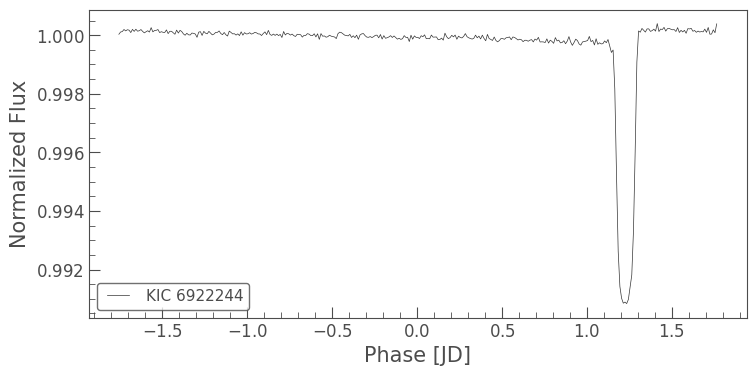

In [108]:
lc.remove_nans().flatten(window_length=401).fold(period=3.5225).bin(time_bin_size=0.01).plot();